# Credit Risk and Loan Approval Analysis

This project analyzes a loan approval dataset to understand which applicant and loan characteristics are connected with loan approval decisions, and how they are connected. The main goal of the project is to explore the dataset, check data quality and prepare it for analysis, create visualizations such as plots/histograms, engineer new features, and formulate and test hypotheses about factors related to loan approval and credit risk.

This project was completed by a team of two. The work was divided: Kuznetsova Aleksandra 256 focused on dataset description, data quality check and cleanup, general overview, using FastAPI as REST API and the Telegram bot, while Tymanian Syuzi 256 concentrated on descriptive statistics, detailed overview and data transformation, and the Streamlit web interface. Each participant made a hypothesis, both actively participated in reviewing each other's code, discussing intermediate results, and editing the final report.

## Data Loading

We start from the import the needed Python libraries and load the loan approval dataset. We also display the first rows of the dataset to check that the file was loaded and looked correctly.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("loan_data.csv")

In [3]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


The dataset was loaded successfully. 

## Dataset Description

We find the size of the dataset, column names, and data types. This helps us understand what kind of information is available for analysis and which variables are numerical or categorical.

In [4]:
df.shape

(45000, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

The dataset contains 45000 rows and 14 columns. Each row represents one loan application.

The dataset is synthetic, belongs to the financial field (loan approval and credit risk analysis). It includes numerical features: applicant age, annual income in USD, employment experience, loan amount in USD, interest rate, loan percent income, credit history length, and credit score. And also categorical features: gender, education level, home ownership, loan intent, and previous loan defaults. The target variable is `loan_status`, which represents the loan approval decision.

## Data Quality Check

We check the dataset for missing and unusual values, and duplicated rows. This helps decide whether data cleaning is required before further analysis.

In [6]:
df.isna().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [9]:
df.select_dtypes(include="str").nunique()

person_gender                     2
person_education                  5
person_home_ownership             4
loan_intent                       6
previous_loan_defaults_on_file    2
dtype: int64

In [10]:
for column in df.select_dtypes(include="str").columns:
    print(column)
    print(df[column].unique())
    print()

person_gender
<StringArray>
['female', 'male']
Length: 2, dtype: str

person_education
<StringArray>
['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate']
Length: 5, dtype: str

person_home_ownership
<StringArray>
['RENT', 'OWN', 'MORTGAGE', 'OTHER']
Length: 4, dtype: str

loan_intent
<StringArray>
[         'PERSONAL',         'EDUCATION',           'MEDICAL',
           'VENTURE',   'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
Length: 6, dtype: str

previous_loan_defaults_on_file
<StringArray>
['No', 'Yes']
Length: 2, dtype: str



In [11]:
unusual_values = {
    "age_over_100": (df["person_age"] > 100).sum(),
    "age_under_18": (df["person_age"] < 18).sum(),
    "income_zero_or_negative": (df["person_income"] <= 0).sum(),
    "loan_amount_zero_or_negative": (df["loan_amnt"] <= 0).sum(),
    "loan_percent_income_over_1": (df["loan_percent_income"] > 1).sum(),
    "employment_experience_greater_than_age": (df["person_emp_exp"] > df["person_age"]).sum()
}

unusual_values

{'age_over_100': np.int64(7),
 'age_under_18': np.int64(0),
 'income_zero_or_negative': np.int64(0),
 'loan_amount_zero_or_negative': np.int64(0),
 'loan_percent_income_over_1': np.int64(0),
 'employment_experience_greater_than_age': np.int64(0)}

The data quality check shows that the dataset has no missing values and no duplicated rows. The categorical variables look logical: gender has 2 categories, education has 5 categories, home ownership has 4 categories, loan intent has 6 categories, and previous defaults has 2 categories.

The numerical checks do not show negative or zero values for annual income or loan amount. However, there are 7 observations where applicant age is greater than 100, which is unrealistic for this project. These rows will be removed during data cleaning.

## Data Cleanup

In [12]:
df_clean = df[df["person_age"] <= 100].copy()

df_clean.shape

(44993, 14)

In [13]:
(df_clean["person_age"] > 100).sum()

np.int64(0)

After removing the unrealistic age values, the cleaned dataset contains 44993 rows and 14 columns. The check confirms that there are no remaining observations with applicant age greater than 100.

## Descriptive Statistics

We calculate descriptive statistics for the main numerical variables. We do it with applicant age, annual income in USD, employment experience, loan amount in USD, interest rate, loan percent income, credit history length, and credit score. These statistics help us understand the typical applicant and identify variation in financial and credit-related variables.

In [14]:
numeric_columns = [
    "person_age",
    "person_income",
    "person_emp_exp",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "credit_score"
]

In [15]:
descriptive_stats = df_clean[numeric_columns].describe().T

descriptive_stats = descriptive_stats.rename(
    columns={
        "25%": "Q1",
        "50%": "median",
        "75%": "Q3"
    }
)

descriptive_stats["IQR"] = descriptive_stats["Q3"] - descriptive_stats["Q1"]

descriptive_stats = descriptive_stats[
    ["count", "mean", "min", "Q1", "median", "Q3", "max", "std", "IQR"]
].round(2)

descriptive_stats

,count,mean,min,Q1,median,Q3,max,std,IQR
person_age,44993.0,27.75,20.00,24.00,26.00,30.00,94.00,5.91,6.00
person_income,44993.0,79908.45,8000.00,47195.00,67046.00,95778.00,2448661.00,63322.13,48583.00
person_emp_exp,44993.0,5.39,0.00,1.00,4.00,8.00,76.00,5.93,7.00
loan_amnt,44993.0,9583.18,500.00,5000.00,8000.00,12237.00,35000.00,6314.80,7237.00
loan_int_rate,44993.0,11.01,5.42,8.59,11.01,12.99,20.00,2.98,4.40
loan_percent_income,44993.0,0.14,0.00,0.07,0.12,0.19,0.66,0.09,0.12
cb_person_cred_hist_length,44993.0,5.87,2.00,3.00,4.00,8.00,30.00,3.88,5.00
credit_score,44993.0,632.59,390.00,601.00,640.00,670.00,784.00,50.40,69.00


The descriptive statistics show that applicants in the cleaned dataset are relatively young. The mean age is about 27.75 years, while the median age is 26 years. The maximum age after cleaning is 94 years.

Income has a large spread. The mean annual income is about USD 79,908, while the median annual income is USD 67,046. Since the mean is higher than the median, the income distribution is likely right-skewed: a smaller number of very high annual income values pull the mean upward.

The average loan amount is about USD 9,583, while the median loan amount is USD 8,000. This difference suggests that larger loan requests increase the average. The maximum loan amount is USD 35,000.

The average interest rate is around 11.01%, and the median is also 11.01%. This indicates that the center of the interest rate distribution is around 11%, although rates vary from 5.42% to 20%.

The variable `loan_percent_income` has a mean of 0.14 and a median of 0.12. This means that, for a typical applicant, the requested loan amount represents about 12% of annual income. However, the maximum value is 0.66, so some applicants request loans that represent a much larger share of their income.

The average credit history length is about 5.87 years, while the median is 4 years. Credit scores range from 390 to 784, with a mean of about 632.59 and a median of 640.

## General Overview

We create a general overview of the dataset using simple visualizations. We examine the distributions of key numerical variables, the distribution of loan approval status, and the relationship between annual income and loan amount, both measured in USD.

## Numerical Distributions

We visualize the distributions of the main numerical variables. It helps us to understand how applicant annual income in USD, loan amount in USD, interest rate, and credit score are distributed in the dataset.

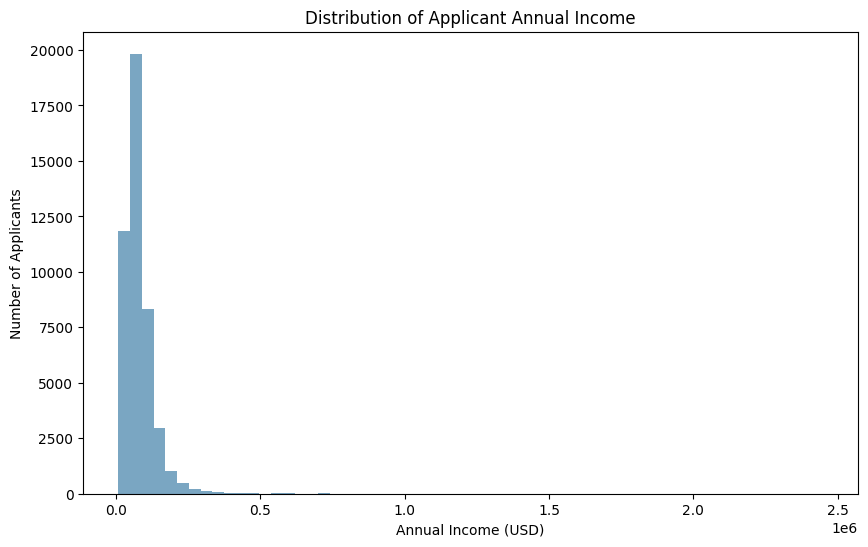

In [16]:
plt.figure(figsize=(10, 6))
plt.hist(df_clean["person_income"], bins=60, color="#7AA6C2")
plt.title("Distribution of Applicant Annual Income")
plt.xlabel("Annual Income (USD)")
plt.ylabel("Number of Applicants")
plt.show()

The annual income distribution is strongly right-skewed. Most applicants have relatively low or medium income values, while a smaller number of applicants have very high annual income. This confirms that the median annual income is more representative of a typical applicant than the mean annual income.

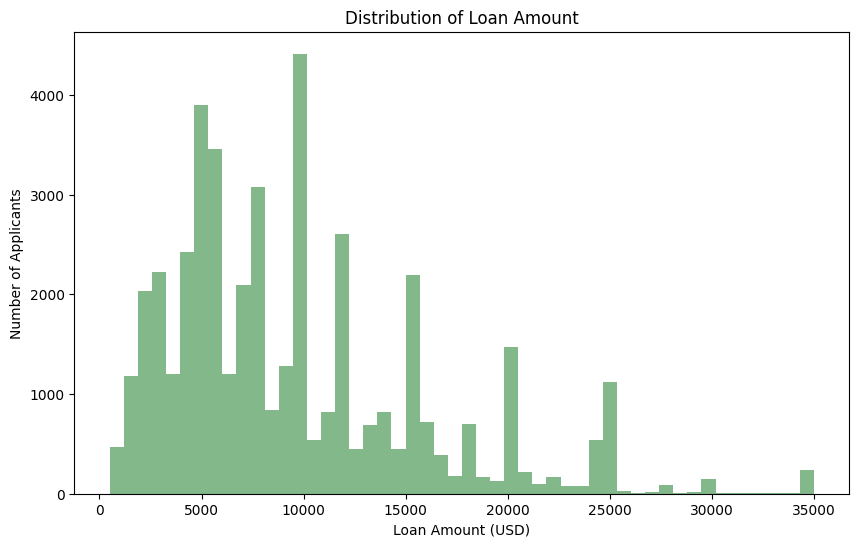

In [17]:
plt.figure(figsize=(10, 6))
plt.hist(df_clean["loan_amnt"], bins=50, color="#83B88B")
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount (USD)")
plt.ylabel("Number of Applicants")
plt.show()

There are multiple jumps and drops in number of applicants happening one after another. The most requested loans are concentrated in the lower and middle range, while fewer applicants request very large loans. The maximum loan amount is USD 35,000, but the median is much lower, which shows that large loans are less common.

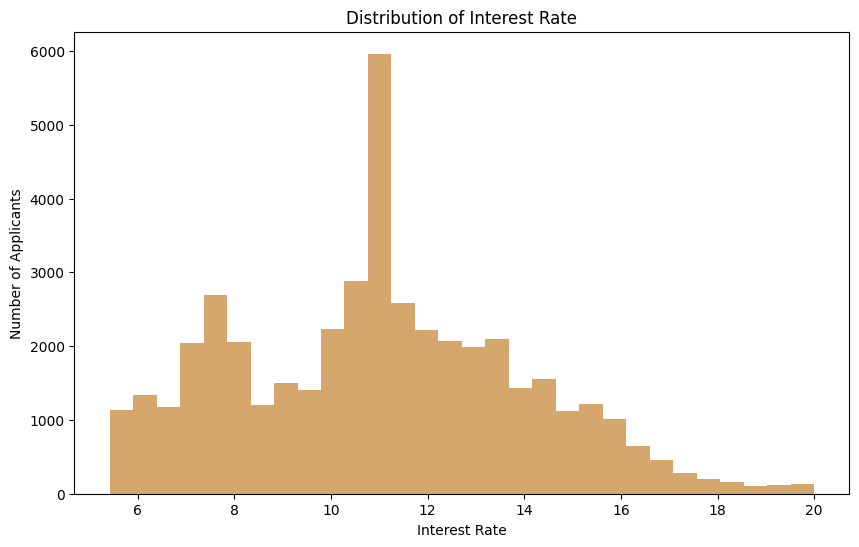

In [18]:
plt.figure(figsize=(10, 6))
plt.hist(df_clean["loan_int_rate"], bins=30, color="#D6A76C")
plt.title("Distribution of Interest Rate")
plt.xlabel("Interest Rate")
plt.ylabel("Number of Applicants")
plt.show()

Between about 5.5% and 10%, the number of applications fluctuates. The distribution then reaches a maximum around 11%. After this peak, the number of applications generally decreases to the minimum as the interest rate increases.

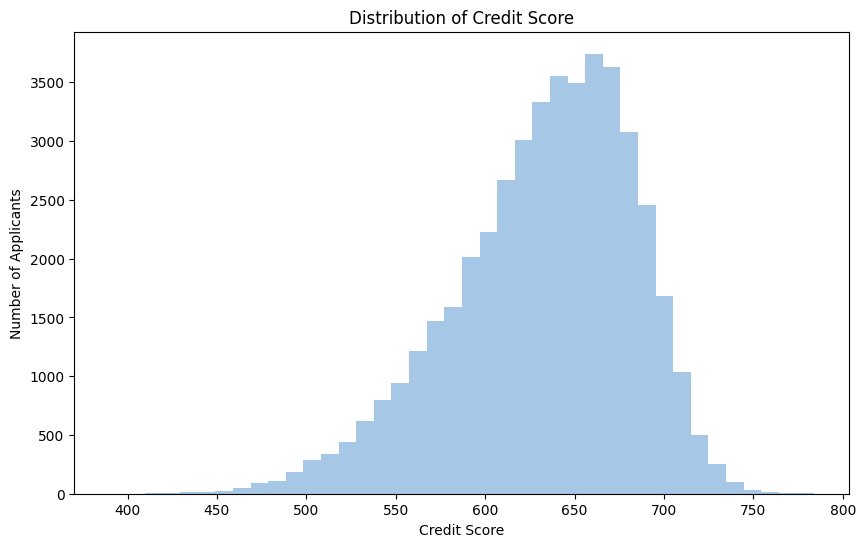

In [19]:
plt.figure(figsize=(10, 6))
plt.hist(df_clean["credit_score"], bins=40, color="#A7C7E7")
plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Number of Applicants")
plt.show()

Credit scores are mostly concentrated around 650. This suggests that most applicants have high credit score.

### Loan Status Distribution

Next, we examine the distribution of the target variable `loan_status`. This is important because the project focuses on loan approval decisions.

In [20]:
loan_status_counts = df_clean["loan_status"].value_counts().sort_index()
loan_status_percent = df_clean["loan_status"].value_counts(normalize=True).sort_index() * 100

loan_status_summary = pd.DataFrame({
    "status": ["Rejected", "Approved"],
    "count": loan_status_counts.values,
    "percentage": loan_status_percent.round(2).values
})

loan_status_summary

,status,count,percentage
0,Rejected,34993,77.77
1,Approved,10000,22.23


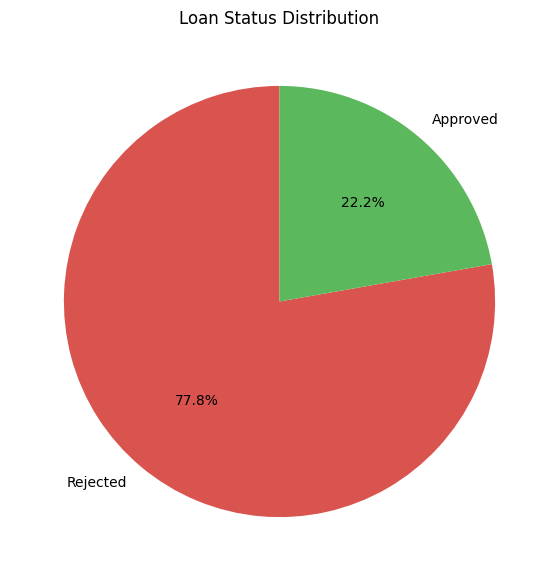

In [21]:
plt.figure(figsize=(7, 7))
plt.pie(
    loan_status_counts,
    labels=["Rejected", "Approved"],
    colors=["#d9534f", "#5cb85c"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Loan Status Distribution")
plt.show()

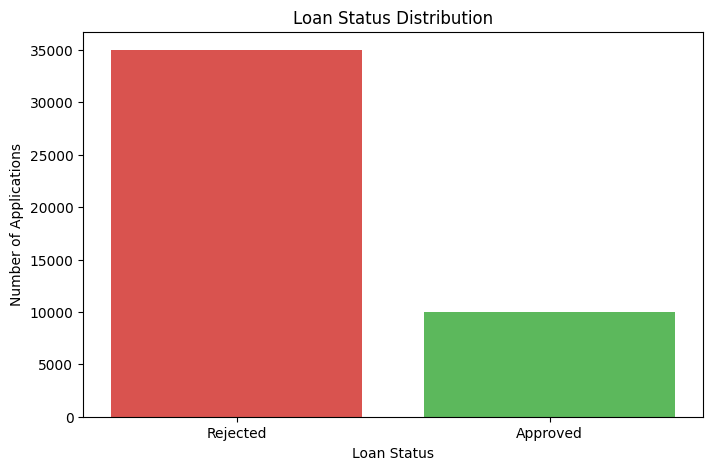

In [22]:
plt.figure(figsize=(8, 5))
plt.bar(
    ["Rejected", "Approved"],
    loan_status_counts,
    color=["#d9534f", "#5cb85c"]
)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")
plt.show()

The dataset contains more rejected applications than approved applications. Around 77.8% of applications were rejected, while about 22.2% were approved. This means that the target variable is imbalanced.

### Loan Amount Boxplot

A boxplot is used to examine the spread of requested loan amounts in USD. The box shows the middle 50% of values, the red line shows the median, the green point shows the mean, and the red points on the right show unusually large loan amounts compared with the main part of the data.

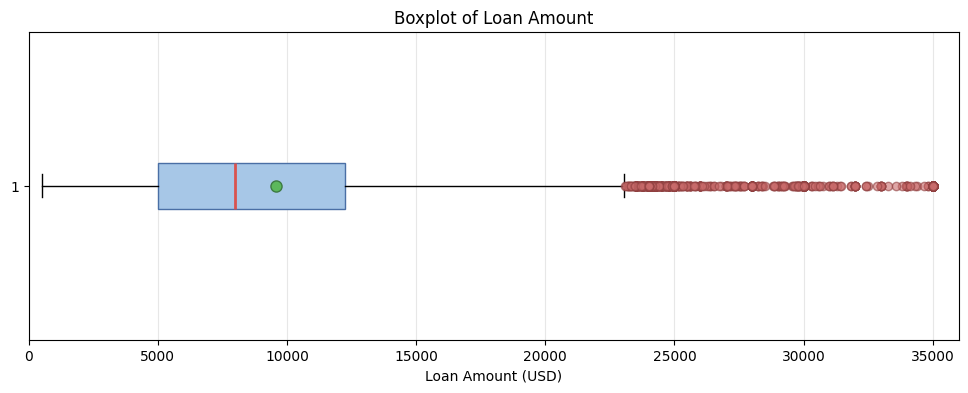

In [23]:
plt.figure(figsize=(12, 4))

plt.boxplot(
    df_clean["loan_amnt"],
    vert=False,
    patch_artist=True,
    showmeans=True,
    boxprops=dict(facecolor="#A7C7E7", color="#4A6FA5"),
    medianprops=dict(color="#D9534F", linewidth=2),
    meanprops=dict(
        marker="o",
        markerfacecolor="#5CB85C",
        markeredgecolor="#3D7A42",
        markersize=8
    ),
    flierprops=dict(
        marker="o",
        markerfacecolor="#C96B6B",
        markeredgecolor="#8F3F3F",
        markersize=6,
        alpha=0.6
    )
)

plt.title("Boxplot of Loan Amount")
plt.xlabel("Loan Amount (USD)")
plt.xlim(0, 36000)
plt.grid(axis="x", alpha=0.3)

plt.show()

The boxplot shows that the median loan amount is around USD 8,000, while the mean loan amount is higher, approximately USD 9,583. This means that larger loan requests pull the average upward. Most loan amounts are concentrated in the lower and middle range, while the red points on the right represent unusually large requested loan amounts. These values are not necessarily errors, because large loan requests may be valid applications.

### Income and Loan Amount Relationship

We use scatter plots to examine the relationship between applicant annual income and requested loan amount, both measured in USD. Each point represents one loan application. The first plot uses the full cleaned dataset, while the second plot excludes the top 1% of annual income values for better visualization.

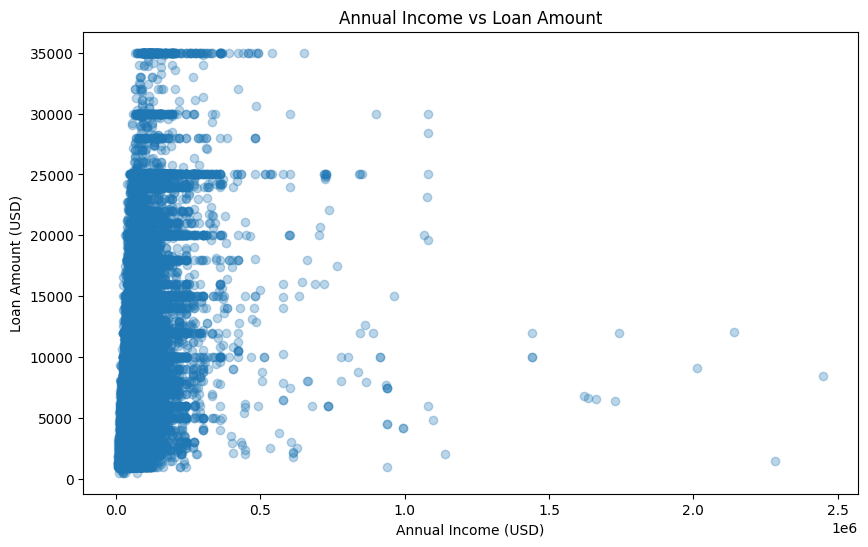

In [24]:
plt.figure(figsize=(10, 6))
plt.scatter(df_clean["person_income"], df_clean["loan_amnt"], alpha=0.3)

plt.title("Annual Income vs Loan Amount")
plt.xlabel("Annual Income (USD)")
plt.ylabel("Loan Amount (USD)")
plt.show()

The full scatter plot shows that most applicants are concentrated in the lower annual income area, while a smaller number of very high-income applicants stretch the x-axis. Because of these high annual income values, the main concentration of points is difficult to see carefully.

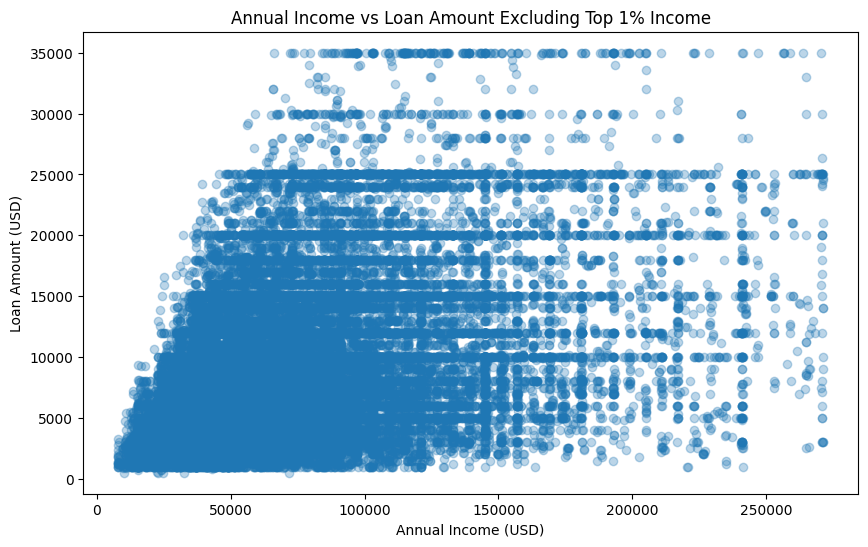

In [25]:
income_99 = df_clean["person_income"].quantile(0.99)

filtered_income = df_clean[df_clean["person_income"] <= income_99]

plt.figure(figsize=(10, 6))
plt.scatter(filtered_income["person_income"], filtered_income["loan_amnt"], alpha=0.3)

plt.title("Annual Income vs Loan Amount Excluding Top 1% Income")
plt.xlabel("Annual Income (USD)")
plt.ylabel("Loan Amount (USD)")
plt.show()

After excluding the top 1% of annual income values for visualization, the relationship between annual income and loan amount becomes easier to analyze. Most applicants are concentrated in the lower and middle annual income ranges, and loan amounts vary within these income groups.

## Detailed Overview

We compare loan approval patterns across different applicant and loan groups. Unlike the general overview, these outputs focus on relationships between variables and differences between categories.

The comparisons in this section describe associations observed in the dataset. They do not establish causal relationships between applicant characteristics and loan approval.

### Approval Rate by Loan Intent

First, we compare approval rates across different loan purposes. This helps us understand whether some loan intents are associated with higher or lower approval rates.

In [26]:
approval_by_intent = (
    df_clean.groupby("loan_intent")["loan_status"].mean().sort_values(ascending=False) * 100
)

approval_by_intent

loan_intent
DEBTCONSOLIDATION    30.272918
MEDICAL              27.819373
HOMEIMPROVEMENT      26.301484
PERSONAL             20.143027
EDUCATION            16.959895
VENTURE              14.433781
Name: loan_status, dtype: float64

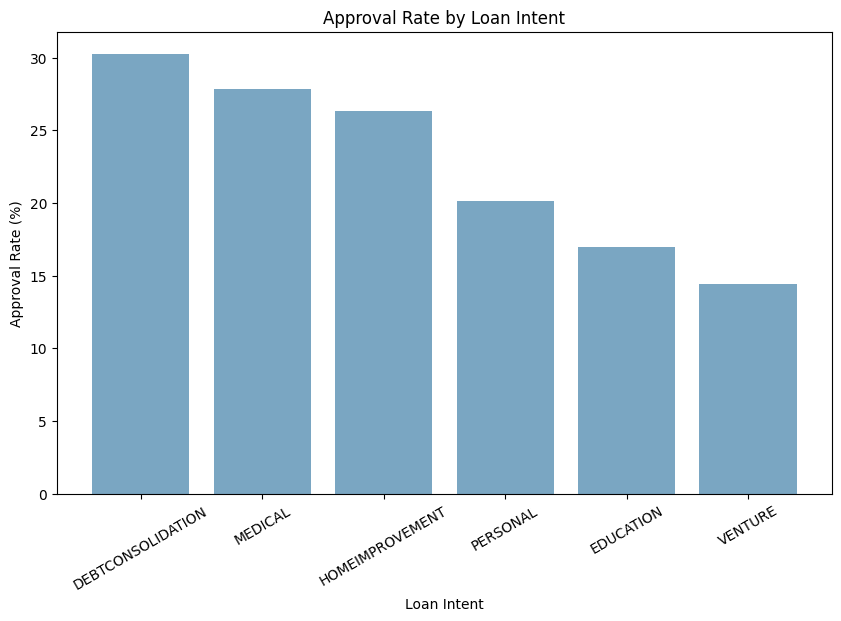

In [27]:
plt.figure(figsize=(10, 6))
plt.bar(
    approval_by_intent.index,
    approval_by_intent.values,
    color="#7AA6C2"
)

plt.title("Approval Rate by Loan Intent")
plt.xlabel("Loan Intent")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=30)
plt.show()

Approval rates differ across loan purposes. Debt consolidation has the highest approval rate at approximately 30.27%, followed by medical loans at 27.82% and home improvement loans at 26.30%. Venture loans have the lowest approval rate at approximately 14.43%.

### Approval Rate by Previous Defaults

Previous loan defaults are related to credit risk. We compare approval rates for applicants with and without previous defaults.

In [28]:
defaults_summary = (
    df_clean.groupby("previous_loan_defaults_on_file")["loan_status"].agg(["count", "sum", "mean"])
)

defaults_summary = defaults_summary.rename(
    columns={
        "count": "applications",
        "sum": "approved_applications",
        "mean": "approval_rate"
    }
)

defaults_summary["approval_rate"] = (defaults_summary["approval_rate"] * 100).round(2)

defaults_summary

,applications,approved_applications,approval_rate
previous_loan_defaults_on_file,,,
No,22137,10000,45.17
Yes,22856,0,0.00


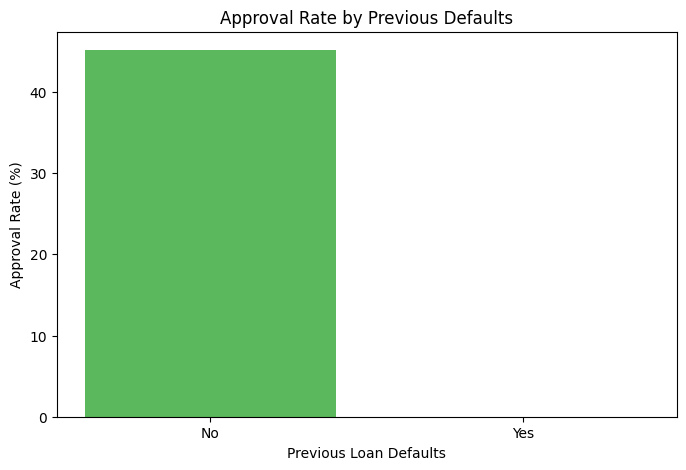

In [29]:
plt.figure(figsize=(8, 5))

plt.bar(
    defaults_summary.index,
    defaults_summary["approval_rate"],
    color=["#5CB85C", "#D9534F"]
)

plt.title("Approval Rate by Previous Defaults")
plt.xlabel("Previous Loan Defaults")
plt.ylabel("Approval Rate (%)")
plt.show()

Applicants with previous defaults are present in the dataset, but their approval rate is 0%. In contrast, applicants without previous defaults have an approval rate of approximately 45.17%. Previous default history is therefore strongly associated with the loan approval decision in this dataset.

### Interest Rate by Loan Status

We compare interest rates for approved and rejected applications. This helps us understand whether approved and rejected loans differ in their interest rate distributions.

In [30]:
interest_by_status = (
    df_clean.groupby("loan_status")["loan_int_rate"].agg(["mean", "median", "std"])
)

interest_by_status.index = ["Rejected", "Approved"]

interest_by_status.round(2)

,mean,median,std
Rejected,10.48,10.85,2.73
Approved,12.86,12.98,3.07


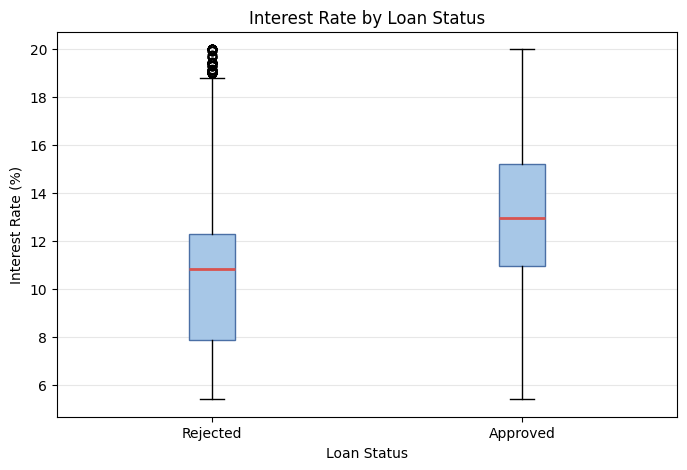

In [31]:
approved_rates = df_clean[df_clean["loan_status"] == 1]["loan_int_rate"]
rejected_rates = df_clean[df_clean["loan_status"] == 0]["loan_int_rate"]

plt.figure(figsize=(8, 5))
plt.boxplot(
    [rejected_rates, approved_rates],
    tick_labels=["Rejected", "Approved"],
    patch_artist=True,
    boxprops=dict(facecolor="#A7C7E7", color="#4A6FA5"),
    medianprops=dict(color="#D9534F", linewidth=2)
)

plt.title("Interest Rate by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Interest Rate (%)")
plt.grid(axis="y", alpha=0.3)
plt.show()

Approved applications have higher interest rates than rejected applications. The median interest rate is 12.98% for approved applications and 10.85% for rejected applications. The middle 50% of interest rates are also higher in the approved group.

### Loan Percent Income by Loan Status

`loan_percent_income` shows the requested loan amount as a percentage of annual income. We compare this ratio for approved and rejected applications.

In [32]:
loan_percent_by_status = (
    df_clean.groupby("loan_status")["loan_percent_income"].agg(["mean", "median", "std"]) * 100
)

loan_percent_by_status.index = ["Rejected", "Approved"]

loan_percent_by_status.round(2)

,mean,median,std
Rejected,12.18,11.0,7.13
Approved,20.25,20.0,10.65


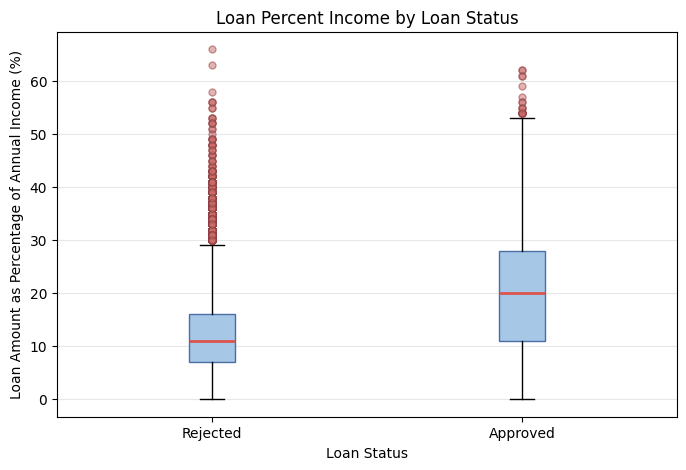

In [33]:
approved_loan_percent = df_clean[df_clean["loan_status"] == 1]["loan_percent_income"] * 100
rejected_loan_percent = df_clean[df_clean["loan_status"] == 0]["loan_percent_income"] * 100

plt.figure(figsize=(8, 5))
plt.boxplot(
    [rejected_loan_percent, approved_loan_percent],
    tick_labels=["Rejected", "Approved"],
    patch_artist=True,
    boxprops=dict(facecolor="#A7C7E7", color="#4A6FA5"),
    medianprops=dict(color="#D9534F", linewidth=2),
    flierprops=dict(
        marker="o",
        markerfacecolor="#C96B6B",
        markeredgecolor="#8F3F3F",
        markersize=5,
        alpha=0.5
    )
)

plt.title("Loan Percent Income by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount as Percentage of Annual Income (%)")
plt.grid(axis="y", alpha=0.3)
plt.show()

Approved applications have a higher requested loan amount relative to annual income than rejected applications. The median is 20% for approved applications and 11% for rejected applications. The approved group also has a wider spread of values.

### Approval Rate by Home Ownership

Home ownership may reflect differences in applicants' financial situation. We check whether approval rates differ across home ownership categories.

In [34]:
approval_by_home = (
    df_clean.groupby("person_home_ownership")["loan_status"].agg(["count", "mean"])
)

approval_by_home = approval_by_home.rename(
    columns={
        "count": "applications",
        "mean": "approval_rate"
    }
)

approval_by_home["approval_rate"] = (approval_by_home["approval_rate"] * 100).round(2)

approval_by_home = approval_by_home.sort_values("approval_rate", ascending=False)

approval_by_home

,applications,approval_rate
person_home_ownership,,
OTHER,117,33.33
RENT,23440,32.40
MORTGAGE,18485,11.60
OWN,2951,7.52


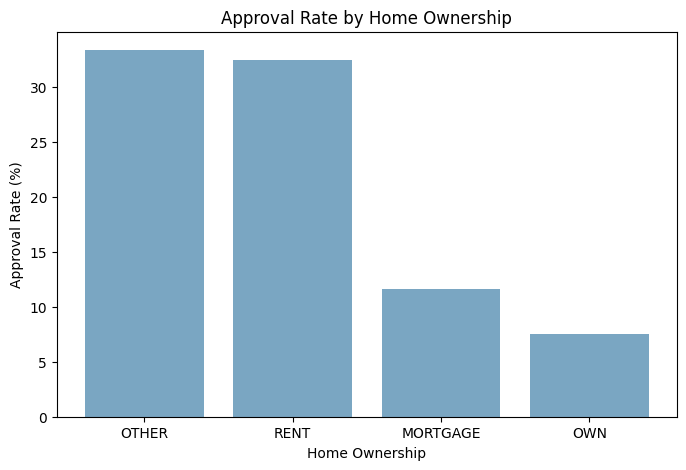

In [35]:
plt.figure(figsize=(8, 5))
plt.bar(
    approval_by_home.index,
    approval_by_home["approval_rate"],
    color="#7AA6C2"
)

plt.title("Approval Rate by Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Approval Rate (%)")
plt.show()

Approval rates differ across home ownership categories. RENT applicants have a relatively high approval rate of 32.40%, while the rates for MORTGAGE and OWN applicants are much lower at 11.60% and 7.52%.

The OTHER category has the highest rate at 33.33%, but it contains only 117 applications, so this result is less representative than the results for the larger groups.

### Annual Income and Loan Amount by Loan Status

We examine the relationship between applicants' annual income and requested loan amount. Loan status is represented by color, which allows us to compare three variables on the same figure. The top 1% of annual income values are excluded to make the main concentration of observations easier to see.

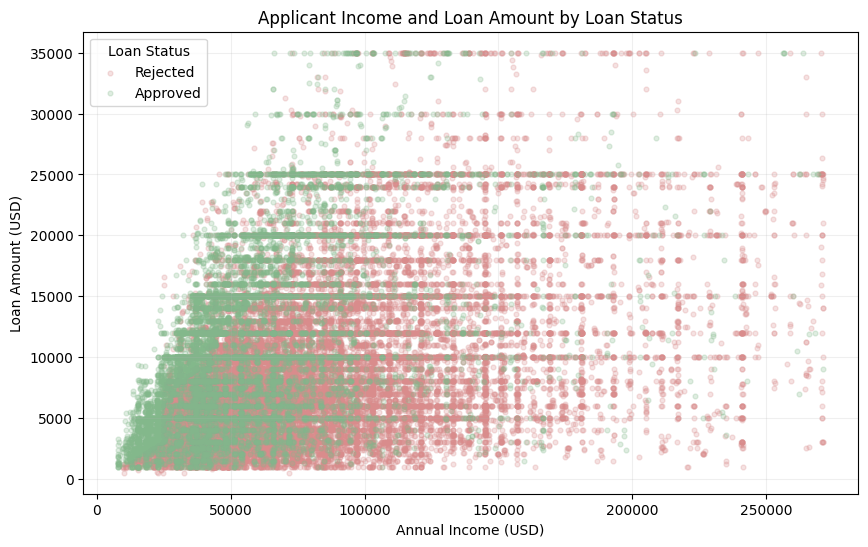

In [36]:
rejected = filtered_income[filtered_income["loan_status"] == 0]
approved = filtered_income[filtered_income["loan_status"] == 1]

plt.figure(figsize=(10, 6))

plt.scatter(
    rejected["person_income"],
    rejected["loan_amnt"],
    color="#D98C8C",
    alpha=0.25,
    s=12,
    label="Rejected"
)

plt.scatter(
    approved["person_income"],
    approved["loan_amnt"],
    color="#83B88B",
    alpha=0.25,
    s=12,
    label="Approved"
)

plt.title("Applicant Income and Loan Amount by Loan Status")
plt.xlabel("Annual Income (USD)")
plt.ylabel("Loan Amount (USD)")
plt.legend(title="Loan Status")
plt.grid(alpha=0.2)
plt.show()

The plot shows a positive relationship between annual income and the range of requested loan amounts: applicants with higher incomes can request both small and large loans. Approved applications are more concentrated among low- and middle-income applicants with relatively larger loan amounts, while rejected applications cover a wider income range. However, the two groups overlap substantially, meaning that income and loan amount together do not fully explain the approval decision.

## Data Transformation

We create two new columns from existing variables. The transformations make credit score and education level easier to compare and will be used in further analysis and hypothesis testing.

### Credit Score Group

We divide the numerical credit score into three categories: low, medium, and high. This leads to easier comparison of approval patterns across credit score levels.

In [37]:
df_clean["credit_score_group"] = pd.cut(
    df_clean["credit_score"],
    bins=[0, 600, 670, float("inf")],
    labels=["Low (<600)", "Medium (600-669)", "High (670+)"],
    right=False
)

df_clean[["credit_score", "credit_score_group"]].head()

,credit_score,credit_score_group
0,561,Low (<600)
1,504,Low (<600)
2,635,Medium (600-669)
3,675,High (670+)
4,586,Low (<600)


In [38]:
df_clean["credit_score_group"].value_counts().sort_index()

credit_score_group
Low (<600)          10828
Medium (600-669)    22879
High (670+)         11286
Name: count, dtype: int64

### Education Level

Education is originally stored as text. We convert the categories into ordered numerical values, where a larger value represents a higher education level. This makes it easier to sort the categories correctly and see relationships between education, income, and loan characteristics.

In [39]:
education_order = {
    "High School": 1,
    "Associate": 2,
    "Bachelor": 3,
    "Master": 4,
    "Doctorate": 5
}

df_clean["education_level"] = (
    df_clean["person_education"].map(education_order)
)

df_clean[["person_education", "education_level"]].drop_duplicates().sort_values("education_level")

,person_education,education_level
1,High School,1
8,Associate,2
3,Bachelor,3
0,Master,4
143,Doctorate,5


## Hypothesis Testing

### Hypothesis 1: Credit Score and Loan Intent

Among applicants without previous loan defaults, applicants with higher credit scores are expected to have higher approval rates for every loan purpose.

This hypothesis considers previous default history, credit score group, loan intent, and loan approval status.

In [40]:
no_defaults = df_clean[
    df_clean["previous_loan_defaults_on_file"] == "No"
]

hypothesis_1 = (
    no_defaults
    .pivot_table(
        index="credit_score_group",
        columns="loan_intent",
        values="loan_status",
        aggfunc="mean",
        observed=False
    )
    .mul(100)
)

hypothesis_1.round(2)

loan_intent,DEBTCONSOLIDATION,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE
credit_score_group,,,,,,
Low (<600),71.32,51.00,67.47,71.68,54.45,49.27
Medium (600-669),55.82,37.01,51.31,51.80,40.50,32.49
High (670+),44.37,30.63,37.90,42.50,35.20,26.29


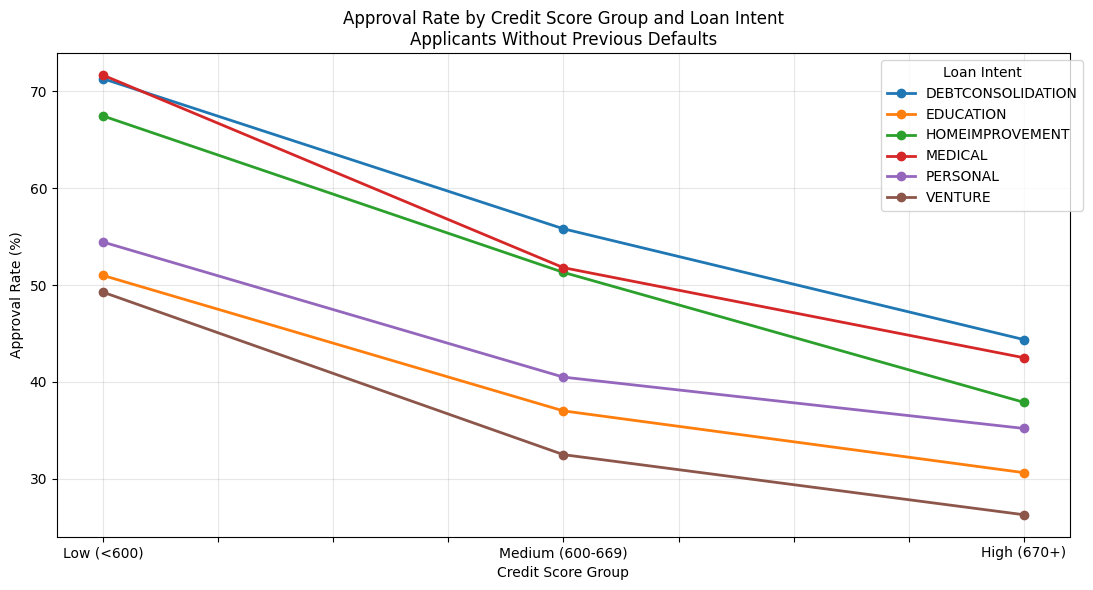

In [41]:
hypothesis_1.plot(
    kind="line",
    marker="o",
    figsize=(11, 6),
    linewidth=2
)

plt.title(
    "Approval Rate by Credit Score Group and Loan Intent\n"
    "Applicants Without Previous Defaults"
)
plt.xlabel("Credit Score Group")
plt.ylabel("Approval Rate (%)")
plt.legend(title="Loan Intent", bbox_to_anchor=(1.02, 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The hypothesis was not supported. For every loan purpose, approval rates decrease rather than increase across the credit score groups. Applicants in the low credit score group have the highest approval rates, while applicants in the high credit score group have the lowest.

Loan purpose also matters: debt consolidation and medical applications generally have higher approval rates, while venture applications have the lowest. Therefore, both credit score group and loan intent are associated with approval status, but the credit score pattern is opposite to the initial expectation.

### Hypothesis 2: Education Level and Home Ownership

Among applicants without previous loan defaults, home ownership was expected to increase the probability of loan approval. We also examined whether this pattern remained consistent across education levels.

In [42]:
no_defaults_home = df_clean[
    (df_clean["previous_loan_defaults_on_file"] == "No") &
    (df_clean["person_home_ownership"].isin(
        ["RENT", "MORTGAGE", "OWN"]
    ))
]

hypothesis_2 = (
    no_defaults_home
    .pivot_table(
        index=["education_level", "person_education"],
        columns="person_home_ownership",
        values="loan_status",
        aggfunc="mean",
        observed=False
    )
    .mul(100)
    .dropna(how="all")
)

hypothesis_2 = hypothesis_2[
    ["RENT", "MORTGAGE", "OWN"]
]

hypothesis_2.round(2)

,person_home_ownership,RENT,MORTGAGE,OWN
education_level,person_education,,,
1,High School,60.47,29.85,21.68
2,Associate,58.49,27.75,20.46
3,Bachelor,57.33,25.88,19.33
4,Master,55.32,25.89,14.55
5,Doctorate,51.56,27.97,14.29


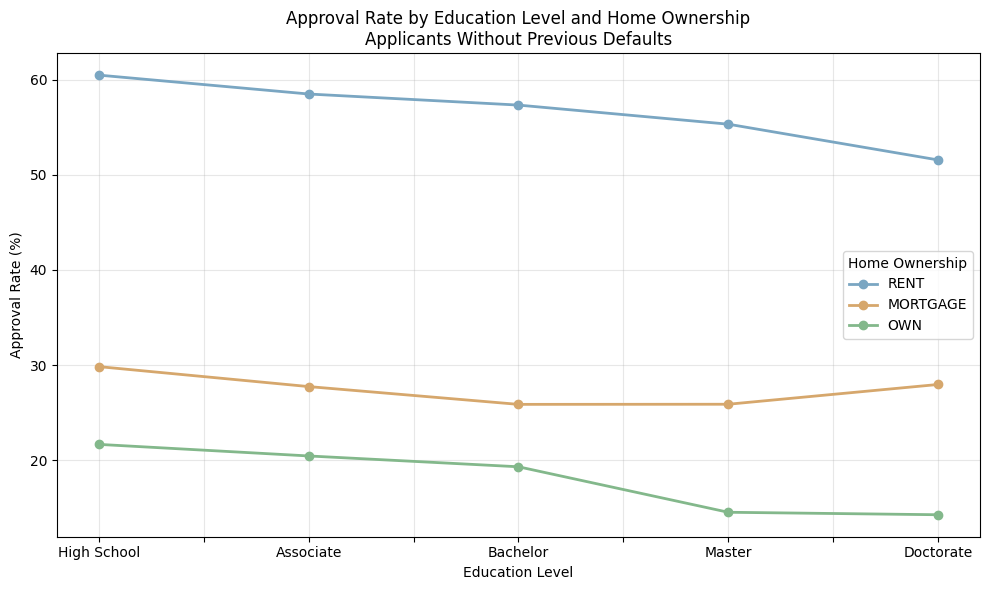

In [43]:
hypothesis_2_plot = hypothesis_2.copy()

hypothesis_2_plot.index = (
    hypothesis_2_plot.index
    .get_level_values("person_education")
)

hypothesis_2_plot.plot(
    kind="line",
    marker="o",
    figsize=(10, 6),
    color=["#7AA6C2", "#D6A76C", "#83B88B"],
    linewidth=2
)

plt.title(
    "Approval Rate by Education Level and Home Ownership\n"
    "Applicants Without Previous Defaults"
)
plt.xlabel("Education Level")
plt.ylabel("Approval Rate (%)")
plt.legend(title="Home Ownership")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The hypothesis was not supported. Among applicants without previous defaults, homeowners have the lowest approval rates at every education level, while renters have the highest rates. Approval rates also generally decrease slightly as education level increases, although this difference is smaller than the difference between home ownership categories. The only exception is the MORTGAGE group, where the approval rate rises slightly from the Master to the Doctorate level. 
To sum up, owning a home and having a higher education level are not associated with higher approval rates in this dataset.

## Discussion

The analysis identified several patterns associated with loan approval status. Previous default history shows the strongest difference: applicants with previous defaults have an approval rate of 0%, while applicants without previous defaults have a substantially higher approval rate.

### Main Findings

- **Loan purpose:** Debt consolidation and medical applications have higher approval rates, while venture applications have the lowest rate.
- **Interest rate:** Approved applications have a higher median interest rate than rejected applications.
- **Loan percent income:** Approved applications request loans representing a larger share of annual income.
- **Home ownership:** Renters have higher approval rates than mortgage holders and homeowners in this dataset.
- **Credit score:** Among applicants without previous defaults, approval rates decrease across the selected credit score groups.
- **Education:** Higher education levels are not associated with higher approval rates in the tested groups.
- **Employment experience:** Employment experience is strongly correlated with applicant age (approximately 0.95), while approval rates differ only slightly across experience groups. It therefore provides limited additional insight in this dataset.

### Hypothesis Results

The first hypothesis was not supported. Higher credit score groups did not have higher approval rates for any loan purpose among applicants without previous defaults.

The second hypothesis was also not supported. Homeowners did not have higher approval rates; renters had the highest approval rate at every education level.

### Final Conclusion

Loan approval patterns in this synthetic dataset differ from several initial expectations. Approval status is associated with a combination of applicant characteristics and loan conditions rather than one variable alone. The results describe patterns in this dataset and should not be interpreted as causal relationships.